# 1.5 決定理論 (Decision Theory)

本ノートブックでは、確率推論によって得られた事後確率分布 $p(\mathcal{C}_k|\mathbf{x})$ や条件付き密度 $p(t|\mathbf{x})$ に基づいて、最適な意思決定（クラス分類や値の予測）を行うための枠組みである **決定理論 (Decision Theory)** を学びます。

PRML 第1章の核となる数理概念：
- **1.5.1 誤識別率の最小化 (Minimizing the misclassification rate)** と決定境界の幾何学（PRML Figure 1.24）
- **1.5.2 期待損失の最小化 (Minimizing the expected loss)** と損失行列（がん診断における偽陰性ペナルティ）
- **1.5.3 棄却オプション (The reject option)** による不確実領域の保留（PRML Figure 1.26）
- **1.5.4 推論と決定の分離 (Inference and decision)**：生成モデル、識別モデル、識別関数の3階層
- **1.5.5 回帰のための損失関数 (Loss functions for regression)**：二乗損失と条件付き平均、Minkowski損失と条件付き中央値・最頻値（PRML Figure 1.27, Figure 1.28）

を完全実装・完全可視化します。

## 1.5.1 誤識別率の最小化 (Minimizing the Misclassification Rate)

入力空間を決定領域 $\mathcal{R}_1, \ldots, \mathcal{R}_K$ に分割し、$\mathbf{x} \in \mathcal{R}_k$ のときクラス $\mathcal{C}_k$ に割り当てます。
2クラス問題において、誤識別確率は以下で与えられます（PRML 式 1.22）：
$$
p(\text{mistake}) = \int_{\mathcal{R}_1} p(\mathbf{x}, \mathcal{C}_2) d\mathbf{x} + \int_{\mathcal{R}_2} p(\mathbf{x}, \mathcal{C}_1) d\mathbf{x}
$$
誤識別確率を最小化するには、各入力 $\mathbf{x}$ について：
$$
p(\mathbf{x}, \mathcal{C}_1) > p(\mathbf{x}, \mathcal{C}_2) \iff p(\mathcal{C}_1|\mathbf{x}) > p(\mathcal{C}_2|\mathbf{x})
$$
が成り立つとき $\mathbf{x} \in \mathcal{R}_1$ と判定すればよいことがわかります。

### PRML Figure 1.24 の再現
2つの同時確率密度 $p(x, \mathcal{C}_1)$ と $p(x, \mathcal{C}_2)$ の交点 $\hat{x}$ が最適な決定境界となります。境界を任意の値 $x_0$ に動かしたとき、誤識別領域（青＋緑＋赤）が最小値からどれだけ増加するかを可視化します。

Plot saved to: result/fig1_24_decision_boundary.png


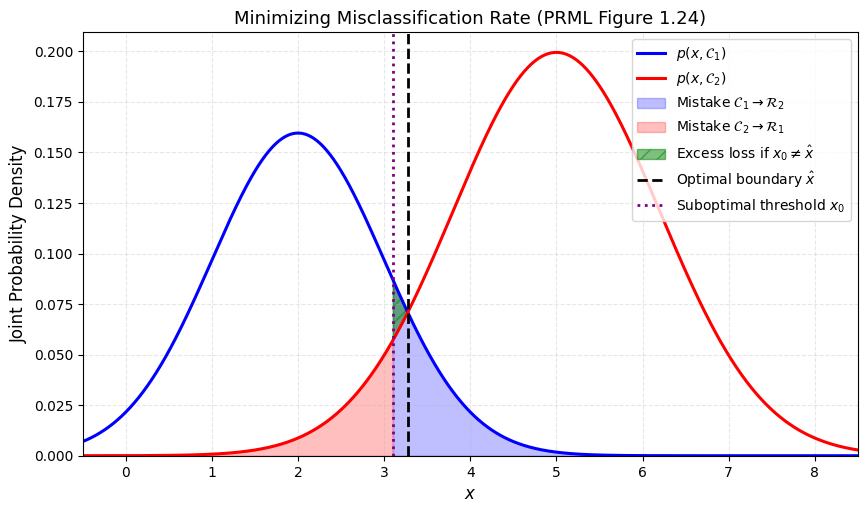

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from common.plot_utils import save_plot, setup_style
setup_style()

# 2クラスの正規分布モデル
mu1, s1, p_c1 = 2.0, 1.0, 0.4
mu2, s2, p_c2 = 5.0, 1.2, 0.6

x = np.linspace(-1, 9, 1000)
p_x_c1 = norm.pdf(x, mu1, s1) * p_c1  # p(x, C1)
p_x_c2 = norm.pdf(x, mu2, s2) * p_c2  # p(x, C2)

# 最適な決定境界 x_hat: p(x, C1) = p(x, C2)
diff = np.abs(p_x_c1 - p_x_c2)
idx_hat = np.argmin(diff[(x > 2.5) & (x < 5.0)]) + np.where((x > 2.5) & (x < 5.0))[0][0]
x_hat = x[idx_hat]

# 任意の非最適境界 x0 (例: x0 < x_hat)
x0 = 3.1

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(x, p_x_c1, 'b-', lw=2.2, label=r'$p(x, \mathcal{C}_1)$')
ax.plot(x, p_x_c2, 'r-', lw=2.2, label=r'$p(x, \mathcal{C}_2)$')

# 領域の塗りつぶし (Figure 1.24 の再現)
# 誤り領域 1: x in R2 (x >= x0) なのに C1
mask_r2 = x >= x0
ax.fill_between(x[mask_r2], 0, p_x_c1[mask_r2], color='blue', alpha=0.25, label=r'Mistake $\mathcal{C}_1 \to \mathcal{R}_2$')

# 誤り領域 2: x in R1 (x < x0) なのに C2
mask_r1 = x <= x0
ax.fill_between(x[mask_r1], 0, p_x_c2[mask_r1], color='red', alpha=0.25, label=r'Mistake $\mathcal{C}_2 \to \mathcal{R}_1$')

# 追加の誤り領域 (x0 と x_hat の差によって生じる領域)
mask_loss = (x >= x0) & (x <= x_hat)
ax.fill_between(x[mask_loss], p_x_c2[mask_loss], p_x_c1[mask_loss], color='green', alpha=0.5, hatch='//',
                label=r'Excess loss if $x_0 \neq \hat{x}$')

ax.axvline(x_hat, color='black', linestyle='--', lw=2.0, label=r'Optimal boundary $\hat{x}$')
ax.axvline(x0, color='purple', linestyle=':', lw=2.0, label=r'Suboptimal threshold $x_0$')

ax.set_title(r'Minimizing Misclassification Rate (PRML Figure 1.24)', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('Joint Probability Density', fontsize=12)
ax.set_xlim(-0.5, 8.5); ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_24_decision_boundary.png')
plt.show()

## 1.5.2 期待損失の最小化 (Minimizing the Expected Loss)

現実の分類タスクでは、誤りの種類によって生じる重大性が異なります（例：悪性腫瘍の見落としと誤診）。
損失行列 (Loss Matrix) $L_{kj}$（真のクラスが $\mathcal{C}_k$ で判定が $\mathcal{C}_j$ のペナルティ）を導入したとき、期待損失は：
$$
\mathbb{E}[L] = \sum_k \sum_j \int_{\mathcal{R}_j} L_{kj} p(\mathbf{x}, \mathcal{C}_k) d\mathbf{x}
$$
となります。これを最小化するには、各 $\mathbf{x}$ に対して条件付き期待損失：
$$
\sum_k L_{kj} p(\mathcal{C}_k | \mathbf{x})
$$
を最小にするクラス $j$ を選択します。2クラス問題で $L_{11}=L_{22}=0$ の場合、決定基準は：
$$
p(\mathcal{C}_1|\mathbf{x}) > \frac{L_{12}}{L_{12} + L_{21}}
$$
となります。悪性腫瘍の見落とし損失 $L_{21} \gg L_{12}$（正常の誤診）の場合、事後確率がわずかでも病気を疑うように閾値が劇的に下がります。

Plot saved to: result/fig1_expected_loss_threshold.png


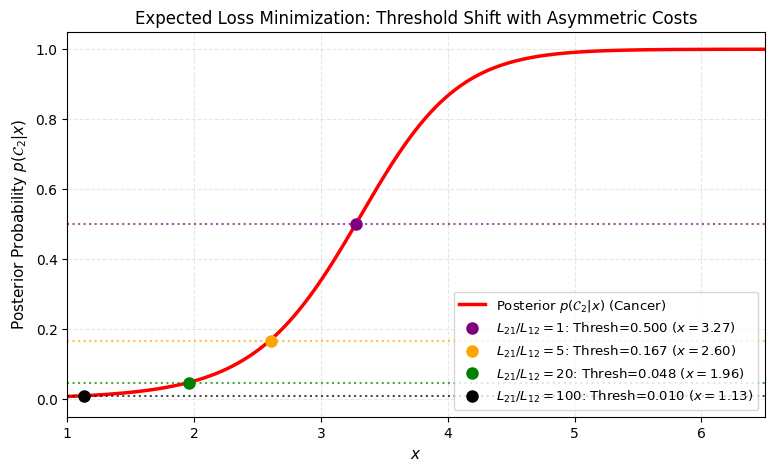

In [2]:
# 損失行列による決定閾値の変化のシミュレーション
# 正常 C1 vs 悪性腫瘍 C2
# L = [[0, 1], [L21, 0]]
L12 = 1.0  # 正常をがんと誤診
L21_list = [1.0, 5.0, 20.0, 100.0]  # がんを見落とすペナルティ

p_x = p_x_c1 + p_x_c2
post_c1 = p_x_c1 / p_x
post_c2 = p_x_c2 / p_x

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, post_c2, 'r-', lw=2.5, label=r'Posterior $p(\mathcal{C}_2 | x)$ (Cancer)')

colors = ['purple', 'orange', 'green', 'black']
for L21, c in zip(L21_list, colors):
    threshold = L12 / (L12 + L21)
    # 決定境界: post_c2 >= threshold
    idx_crit = np.where(post_c2 >= threshold)[0][0]
    crit_x = x[idx_crit]
    ax.axhline(threshold, color=c, linestyle=':', alpha=0.7)
    ax.plot(crit_x, threshold, 'o', color=c, markersize=8,
            label=f'$L_{{21}}/L_{{12}} = {int(L21)}$: Thresh={threshold:.3f} ($x={crit_x:.2f}$)')

ax.set_title('Expected Loss Minimization: Threshold Shift with Asymmetric Costs', fontsize=12)
ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('Posterior Probability $p(\mathcal{C}_2|x)$', fontsize=11)
ax.set_xlim(1.0, 6.5); ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_expected_loss_threshold.png')
plt.show()

## 1.5.3 棄却オプション (The Reject Option)

事後確率 $\max_k p(\mathcal{C}_k|\mathbf{x})$ が閾値 $\theta$ を下回る（確信度が低い）領域では、判定を保留し人間の専門家に診断を委ねる **棄却オプション** が有効です。
閾値 $\theta \in [0.5, 1.0]$ を引き上げるほど、分類誤り率は低下しますが棄却されるサンプルの割合が増加します（PRML Figure 1.26）。

Plot saved to: result/fig1_26_reject_option.png


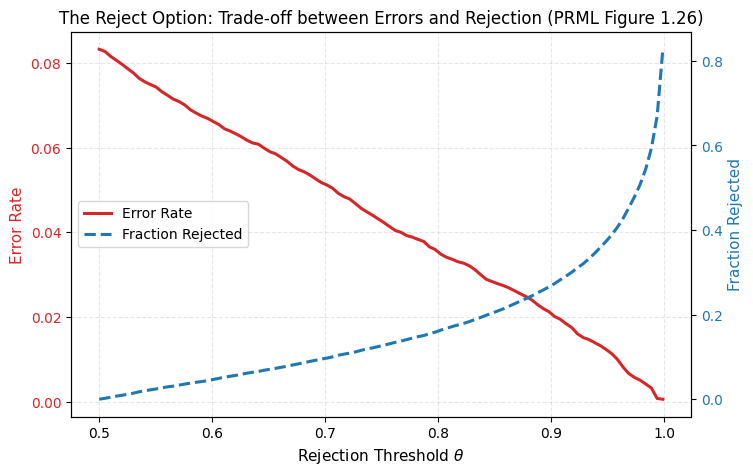

In [3]:
# PRML Figure 1.26 の再現: 誤り率と棄却率のトレードオフ
thetas = np.linspace(0.5, 0.999, 100)

# モンテカルロシミュレーションによる誤り率と棄却率の計測
np.random.seed(42)
N_eval = 20000
labels = np.random.binomial(1, p_c2, N_eval)  # 0: C1, 1: C2
x_samples = np.where(labels == 0, np.random.normal(mu1, s1, N_eval), np.random.normal(mu2, s2, N_eval))

# 各サンプルの事後確率
px1 = norm.pdf(x_samples, mu1, s1) * p_c1
px2 = norm.pdf(x_samples, mu2, s2) * p_c2
post2 = px2 / (px1 + px2)
max_post = np.maximum(post2, 1 - post2)
pred_class = (post2 >= 0.5).astype(int)

rejection_rates = []
error_rates = []

for theta in thetas:
    accepted = max_post >= theta
    n_acc = np.sum(accepted)
    rej_rate = 1.0 - (n_acc / N_eval)
    rejection_rates.append(rej_rate)
    
    if n_acc > 0:
        err = np.mean(pred_class[accepted] != labels[accepted])
    else:
        err = 0.0
    error_rates.append(err)

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel(r'Rejection Threshold $\theta$', fontsize=11)
ax1.set_ylabel('Error Rate', color=color, fontsize=11)
line1 = ax1.plot(thetas, error_rates, color=color, lw=2.2, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Fraction Rejected', color=color, fontsize=11)
line2 = ax2.plot(thetas, rejection_rates, color=color, lw=2.2, linestyle='--', label='Fraction Rejected')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels_legend = [l.get_label() for l in lines]
ax1.legend(lines, labels_legend, loc='center left', fontsize=10)

ax1.set_title('The Reject Option: Trade-off between Errors and Rejection (PRML Figure 1.26)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_26_reject_option.png')
plt.show()

## 1.5.5 回帰のための損失関数 (Loss Functions for Regression)

連続値 $t$ を予測する回帰問題において、一般的な期待損失は二乗損失を用いて以下のように定義されます：
$$
\mathbb{E}[L] = \iint (y(\mathbf{x}) - t)^2 p(\mathbf{x}, t) d\mathbf{x} dt
$$
変分法を用いて $\frac{\delta \mathbb{E}[L]}{\delta y(\mathbf{x})} = 0$ を解くと、最適な予測値は **条件付き平均 (Conditional Expectation)**：
$$
y(\mathbf{x}) = \int t p(t|\mathbf{x}) dt = \mathbb{E}[t|\mathbf{x}]
$$
となります（PRML 式 1.89）。

### Minkowski 損失関数 (PRML Figure 1.27)
二乗損失を一般化した Minkowski 損失：
$$
L_q(y, t) = |y - t|^q
$$
について、指数 $q$ を変えることで以下の最適予測器が得られます：
- $q = 2$: 条件付き平均（正規ノイズに対して最尤）
- $q = 1$: **条件付き中央値 (Conditional Median)**（外れ値に頑健な L1 回帰）
- $q \to 0$: **条件付き最頻値 (Conditional Mode)**（多峰性データに対して最も確率の高いモードを選択）

Plot saved to: result/fig1_27_minkowski_loss.png


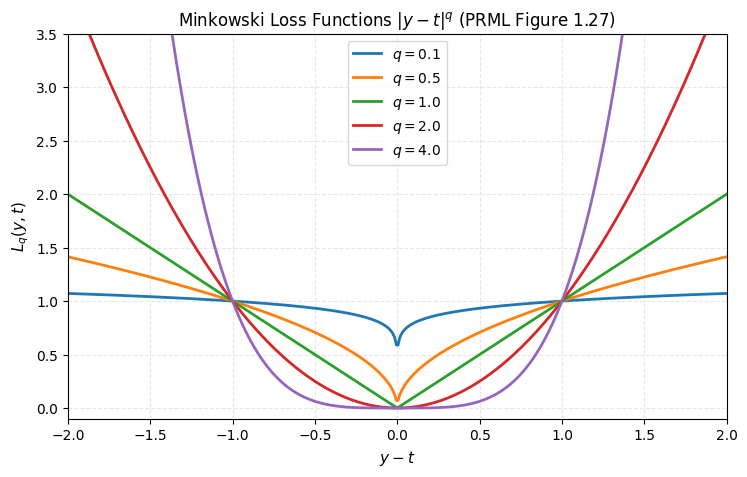

In [4]:
# PRML Figure 1.27 の再現: Minkowski 損失関数の比較
y_minus_t = np.linspace(-2.0, 2.0, 400)
q_values = [0.1, 0.5, 1.0, 2.0, 4.0]

fig, ax = plt.subplots(figsize=(8.5, 5))

for q in q_values:
    loss = np.abs(y_minus_t)**q
    ax.plot(y_minus_t, loss, lw=2.0, label=f'$q = {q}$')

ax.set_ylim(-0.1, 3.5)
ax.set_xlim(-2.0, 2.0)
ax.set_title('Minkowski Loss Functions $|y - t|^q$ (PRML Figure 1.27)', fontsize=12)
ax.set_xlabel('$y - t$', fontsize=11); ax.set_ylabel('$L_q(y, t)$', fontsize=11)
ax.legend(loc='upper center', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig1_27_minkowski_loss.png')
plt.show()

## まとめ

本節では、統計的推論と意思決定を分離する意義を学びました：
1. **最小誤識別率**: 事後確率 $p(\mathcal{C}_k|\mathbf{x})$ の最大化が最適。
2. **最小期待損失**: 非対称な損失行列 $L_{kj}$ の下では、条件付き期待損失 $\sum_k L_{kj} p(\mathcal{C}_k|\mathbf{x})$ を最小化。
3. **棄却基準**: 最大事後確率が閾値 $\theta$ 未満の入力を判定保留とすることで誤りを低減。
4. **回帰損失**: 二乗損失 ($q=2$) は条件付き平均、絶対値損失 ($q=1$) は条件付き中央値、モード探索 ($q \to 0$) は条件付き最頻値へと導く。